## Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

## Metadata

**carID** - An attribute that contains an identifier for each car. <br>
**Brand** - The car’s main brand (e.g. Ford, Toyota) <br>
**model** - The car model <br>
**year** - The year of Registration of the Car <br>
**mileage** - The total reported distance travelled by the car (in
miles) <br>
**tax** - The amount of road tax (in £) that, in 2020, was
applicable to the car in question. <br>
**fuelType** - Type of Fuel used by the car (Diesel, Petrol, Hybrid,
Electric) <br>
**mpg** - Average Miles per Gallon <br>
**engineSize** - Size of Engine in liters (Cubic Decimeters) <br>
**paintQuality%** -
The mechanic’s assessment of the cars’ overall paint 
quality and hull integrity (filled by the mechanic
during evaluation). <br>
**previousOwners** - Number of previous registered owners of the vehicle. <br>
**hasDamage** - 
Boolean marker filled by the seller at the time of
registration stating whether the car is damaged or
not. <br>
**price** - The car’s price when purchased by Cars 4 You (in £).

## Functions

In [2]:
def iqr_outlier_report(df, features, multiplier=1.5, round_digits=2):
    outlier_report = []

    n_rows = len(df)

    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        low_mark = Q1 - multiplier * IQR
        high_mark = Q3 + multiplier * IQR

        outliers_below = df[df[col] < low_mark]
        outliers_above = df[df[col] > high_mark]

        percentage_below = (len(outliers_below) / n_rows) * 100
        percentage_above = (len(outliers_above) / n_rows) * 100

        outlier_report.append({
            "Feature": col,
            "Outliers Below": len(outliers_below),
            "Outliers Above": len(outliers_above),
            "Percentage Below": round(percentage_below, round_digits),
            "Percentage Above": round(percentage_above, round_digits),
            "Low Mark": round(low_mark, round_digits),
            "High Mark": round(high_mark, round_digits)
        })

    return pd.DataFrame(outlier_report)

## Data Understanding

#### Inicial observation

To better understand our data, we will use the *read_csv* (from pandas's library), to visualize our dataset.

In [3]:
cars = pd.read_csv('../original_datasets/train.csv')
cars.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


This inicial visualization allowed us to have a starting point on a few changes that we will make to the data: <br>
- year: Change from a double to integer <br>
- transmission (probably other categorical features too): Exists a few typos (3 row) <br>
- Mileage (other feature might also have this problem): Outliers <br>
- tax (but other features might also have): Null values <br>
- paintQuality%: Feature added after visit to the mechanic (due to project rules we will delete this feature) <br>
- previousOwners (but other features might also have this problem): Negative values where its impossible to have one

In [4]:
cars.shape

(75973, 14)

#### Null values

Null values are a very common problem when dealing with data (especially if the dataset has a lot of rows: 75973). To understand the magnitude of this problem, we use the info (from pandas's library) and (to have a more direct approach) we also use the difference from the lenght of the dataframe to the null values. 

In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


In [6]:
cars.replace("", np.nan, inplace=True)

In [7]:
cars.isna().sum()

carID                0
Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64

In [8]:
for feature in cars.columns:
    null_count = cars[feature].isna().sum()
    null_percentage = (null_count/len(cars)) * 100

    print(f"{feature}: {null_percentage:.2f}%")


carID: 0.00%
Brand: 2.00%
model: 2.00%
year: 1.96%
price: 0.00%
transmission: 2.00%
mileage: 1.93%
fuelType: 1.99%
tax: 10.40%
mpg: 10.43%
engineSize: 2.00%
paintQuality%: 2.01%
previousOwners: 2.04%
hasDamage: 2.04%


After using this method we can clearly see that almost all features have null values. The most prominent ones are the features **tax** and **mpg** that have *10%* of their rows filled with *null* values.

#### Statistical Overview

Going a littel deeper, we can use the method *decribe* to give us statistical analysis of the numerical features. Since we also want to have a look to the categorical features, we included the parameter *include=all*, allowing us to see every feature.

In [9]:
cars.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,75973.0,NaN,NaN,NaN,37986.0,21931.660338,0.0,18993.0,37986.0,56979.0,75972.0
Brand,74452,72,Ford,14808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,74456,735,Focus,6353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,74482.0,NaN,NaN,NaN,2017.096611,2.208704,1970.0,2016.0,2017.0,2019.0,2024.121759
price,75973.0,NaN,NaN,NaN,16881.889553,9736.926322,450.0,10200.0,14699.0,20950.0,159999.0
transmission,74451,40,Manual,38050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,74510.0,NaN,NaN,NaN,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.0
fuelType,74462,34,Petrol,37995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,68069.0,NaN,NaN,NaN,120.329078,65.521176,-91.12163,125.0,145.0,145.0,580.0
mpg,68047.0,NaN,NaN,NaN,55.152666,16.497837,-43.421768,46.3,54.3,62.8,470.8


From the statistical table, we can retrive 3 problems in the data. The 1st problem is about the negative values in a few features. we already knew about this by looking to the dataset, but now we know in which features these negative values appear. 
- mileage
- tax
- mpg
- engineSize
- previousOwners

The 2nd problem, is about outliers. We can see that in the features:
- year
- price (target)
- mileage
- tax
- mpg
- engineSize

The 3rd problem is about the data type of some features. Even though this isn't a major problem we can adjust some type to make our dataset more natural. This features are:
- year
- paintQuality%
- previousOwners

In other issues we also have:
- The trasmission feature has 40 unique values, which goes against our common knowledge of there being generally 3 main types, this can probably be explained with the existence of typos during the storing of the data, which we will have to take into consideration in the data preprocess part of the project, this issue also stands out in the fuelType feature;
- We only have cars until the year 2020, but we can see in the describe method that there are higher values for the 'year' feature.

#### Duplicated values

In [10]:
cars.duplicated().sum()

np.int64(0)

#### Unique values

To understand how many values are present in each feature, we will use the method *nunique()* (for all features) and *unique()* (each feature at a time) to get the number of different values. We will use this method for the numerical and categorical features. <br>

We will also use the method *value_counts* to get the number of times that the value appears in the feature

##### Numerical Features

In [11]:
cars.nunique()

carID             75973
Brand                72
model               735
year                 44
price             11048
transmission         40
mileage           34808
fuelType             34
tax                  65
mpg                 217
engineSize           58
paintQuality%        88
previousOwners       23
hasDamage             1
dtype: int64

In [12]:
cars['year'].unique()

array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

In [13]:
cars['previousOwners'].unique()

array([ 4.        ,  1.        , -2.34030622,  3.        ,  0.        ,
        2.        ,         nan, -2.34565   ,  6.25837066, -2.33512284,
        6.22789796,  6.25823052,  6.23017958, -2.33936045,  6.21772443,
        6.24583495, -2.29943868, -2.34010209, -2.31225953,  6.2482512 ,
       -2.31733109,  6.23308217,  6.24177863, -2.33744529])

In [14]:
cars['tax'].value_counts()

tax
145.0    32861
150.0     7400
30.0      5781
20.0      5610
125.0     4496
         ...  
130.0        1
520.0        1
295.0        1
245.0        1
535.0        1
Name: count, Length: 65, dtype: int64

In [15]:
cars['tax'].min()

-91.12163047754362

##### Categorical features

Here we can see that in the feautres 'Brand', 'model', 'fuelType' and transmission, this can be due to typos during the imputing of data into the dataset, for most cases they are normal typos, like 'TOYOT' meaning Toyota, 'for' meaning Ford, for this issue we will be using Fuzzy Matching (RapidFuzz), in a way to find the closest match in the list of brands we are gonna create. This list will be based on our consideration after observing the unique values of the 'Brand' feature, the same thought process will be used for the 'transmission' and 'fuelType' features.

However in the feature 'model', we also have this typos, however due to the quantity of different models there exists (735 unique models identified), we won't be executing the fuzzy matching in this feature, as we should probably remove it from our consideration due to it creating too many dimensions after executing OneHotEncoder.

In [16]:
cars['Brand'].value_counts()

Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
OYOTA           2
SKOD            1
TOYOT           1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64

In [17]:
cars['Brand'].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

In [18]:
cars['model'].value_counts()

model
 Focus        6353
 C Class      4886
 Fiesta       4130
 Golf         3081
 Corsa        2182
              ... 
M5               1
 gls class       1
Mokka            1
 6 Serie         1
 JETTA           1
Name: count, Length: 735, dtype: int64

In [19]:
cars['model'].unique()

array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

In [20]:
cars['transmission'].value_counts()

transmission
Manual       38050
Semi-Auto    15545
Automatic    14003
anual          804
MANUAL         801
manual         770
Manua          759
unknown        690
 Manual        366
Semi-Aut       332
emi-Auto       325
semi-auto      324
utomatic       313
SEMI-AUTO      309
Automati       304
AUTOMATIC      289
automatic      282
unknow          18
Manual          16
UNKNOWN         14
ANUAL           13
nknown          13
anua            12
SEMI-AUT        11
MANUA           11
emi-auto        10
 MANUAL          9
EMI-AUTO         7
 Manual          7
automati         6
utomati          6
 manual          6
AUTOMATI         6
emi-Aut          5
Other            5
semi-aut         4
manua            2
UTOMATIC         2
manual           1
nknow            1
Name: count, dtype: int64

In [21]:
cars['fuelType'].value_counts()

fuelType
Petrol      37995
Diesel      28474
Hybrid       2043
PETROL        795
etrol         794
Petro         785
petrol        746
iesel         603
diesel        599
Diese         582
DIESEL        582
Other         150
HYBRID         50
hybrid         46
Hybri          43
ybrid          37
petro          18
etro           17
ETROL          16
IESEL          16
PETRO          14
DIESE          10
iese           10
diese           8
Othe            6
ther            6
Electric        4
YBRID           3
OTHER           3
other           2
HYBRI           2
ybri            1
ETRO            1
IESE            1
Name: count, dtype: int64

As we can see, the categorical features have a few *typos* that might impact (negatively) the performance of the model. 

#### Zeros and Negative Values

To get a clear view of which features have negative values, we will get the sum of rows where the value is *less than 0* (x < 0)

In [22]:
cars[cars['engineSize'] == 0]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
64,30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
759,21935,Ford,KA,2018.0,8444,Manual,17000.0,Petrol,145.0,57.7,0.0,51.0,0.0,0.0
1039,9518,BMW,2 Series,2015.0,14700,Automatic,32882.0,Diesel,125.0,60.1,0.0,55.0,0.0,0.0
1057,32528,Hyundai,Tucson,2016.0,13800,Manual,27311.0,Diesel,30.0,61.7,0.0,73.0,1.0,0.0
1519,33804,Hyundai,Tucson,2019.0,15000,Manual,22397.0,Petrol,150.0,34.9,0.0,54.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74469,26630,Ford,Fiesta,2018.0,11463,NaN,18000.0,Petro,145.0,65.7,0.0,82.0,0.0,0.0
75168,20128,Ford,Focus,2018.0,18389,Manual,19000.0,Petrol,NaN,NaN,0.0,48.0,2.0,0.0
75401,47605,Skoda,Fabia,2018.0,11500,Manual,10720.0,Petrol,150.0,64.2,0.0,84.0,4.0,0.0
75405,33307,Hyundai,I10,2018.0,8500,Manual,12948.0,Petrol,145.0,60.1,0.0,46.0,2.0,0.0


In [23]:
negative_values = (cars[['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']] < 0).sum()
negative_values

year                0
price               0
mileage           369
tax               378
mpg                36
engineSize         84
paintQuality%       0
previousOwners    371
dtype: int64

#### Feature Separation 

To facilitate the **Data Visualization** process, we will divide the feature into *non_metric* and *metric* features

In [24]:
non_metric_features = ['Brand', 'model', 'transmission', 'fuelType','hasDamage']
metric_features = cars.columns.drop(non_metric_features).to_list()

In [25]:
metric_features

['carID',
 'year',
 'price',
 'mileage',
 'tax',
 'mpg',
 'engineSize',
 'paintQuality%',
 'previousOwners']

#### Check the variance

Filter method is a method of Feature Selection that can be used to select which features can give better insights and/or predictions of the target in our study. One way to use the filter method, is using the variance of the features, and the features that have *variance = 0* don't provide insights to be used. <br>

Although tho we aren't selecting any features, for now, is a good way to understand which features might not have an impact on the model. 

In [26]:
x = cars.select_dtypes(include=np.number)
x.var()

carID             4.809977e+08
year              4.878373e+00
price             9.480773e+07
mileage           4.897275e+08
tax               4.293025e+03
mpg               2.721786e+02
engineSize        3.288583e-01
paintQuality%     4.418852e+02
previousOwners    2.169674e+00
hasDamage         0.000000e+00
dtype: float64

#### Outliers

To clearly see the outliers we will use the function created *iqr_outlier_report*. Using this function we will see which features need to be adjusted

In [27]:
outlier_df = iqr_outlier_report(cars, metric_features)
outlier_df

,Feature,Outliers Below,Outliers Above,Percentage Below,Percentage Above,Low Mark,High Mark
0,carID,0,0,0.00,0.00,-37986.00,113958.00
1,year,1663,128,2.19,0.17,2011.50,2023.50
2,price,0,2695,0.00,3.55,-5925.00,37075.00
3,mileage,369,3248,0.49,4.28,-30083.12,69933.88
4,tax,16104,4202,21.20,5.53,95.00,175.00
5,mpg,364,836,0.48,1.10,21.55,87.55
6,engineSize,84,632,0.11,0.83,-0.00,3.20
7,paintQuality%,0,0,0.00,0.00,-5.50,134.50
8,previousOwners,371,363,0.49,0.48,-2.00,6.00


After analyzing the table these is what we will do to each feature:
- **carID**: It will be removed from the data (identifier)
- **year**: The main outliers are older cars, so we won't remove them
- **price** and **mileage**: The main outliers are in the upper bound. These outliers are the expensive cars. This is another feature that we won't remove
- **tax**: Has a lot of outliers (21%). We won't remove 21% of our data, so we will convert this feature into a categorical feature  
- **mpg** and **engineSize**: low percentages, so we won't remove
- **paintQuality%**: Because of the project guidelines, we will remove this feature 

## Data Visualization

#### Correlation Heatmap

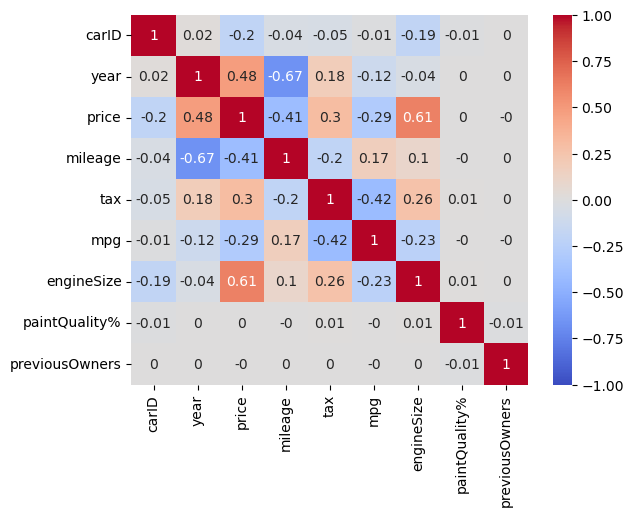

In [28]:
corr = cars[metric_features].corr(method="pearson").round(2)
# Plot heatmap of the correlation matrix
sns.heatmap(data=corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

Our target feature is most correlated with:
- Engine Size (0.61): Meaning that bigger engines strongly correlates with more expensive cars;
- Year (0.48): Newer cars costing more than older ones;
- Mileage (-0.41): Cars with lower mileage usually are cheaper, also noting that mileage correlates strongly with year, which can be used after;
- MPG (-0.29): Meaning that less efficient cars tend to be more expensive;

- Variables like 'paintQuality%' and 'previousOwners' have close to 0 correlation across all features, which won't help predict price;
- 'carID' is a identifier so shouldn't be considering during modelling.

This correlation heatmap revels some moderate correlations, being the strongest a -0.67, although there's not a very strong correlation, there's a few moderate ones that during feature engineering can be worked with to improve our models' perfomance.

#### Histogram

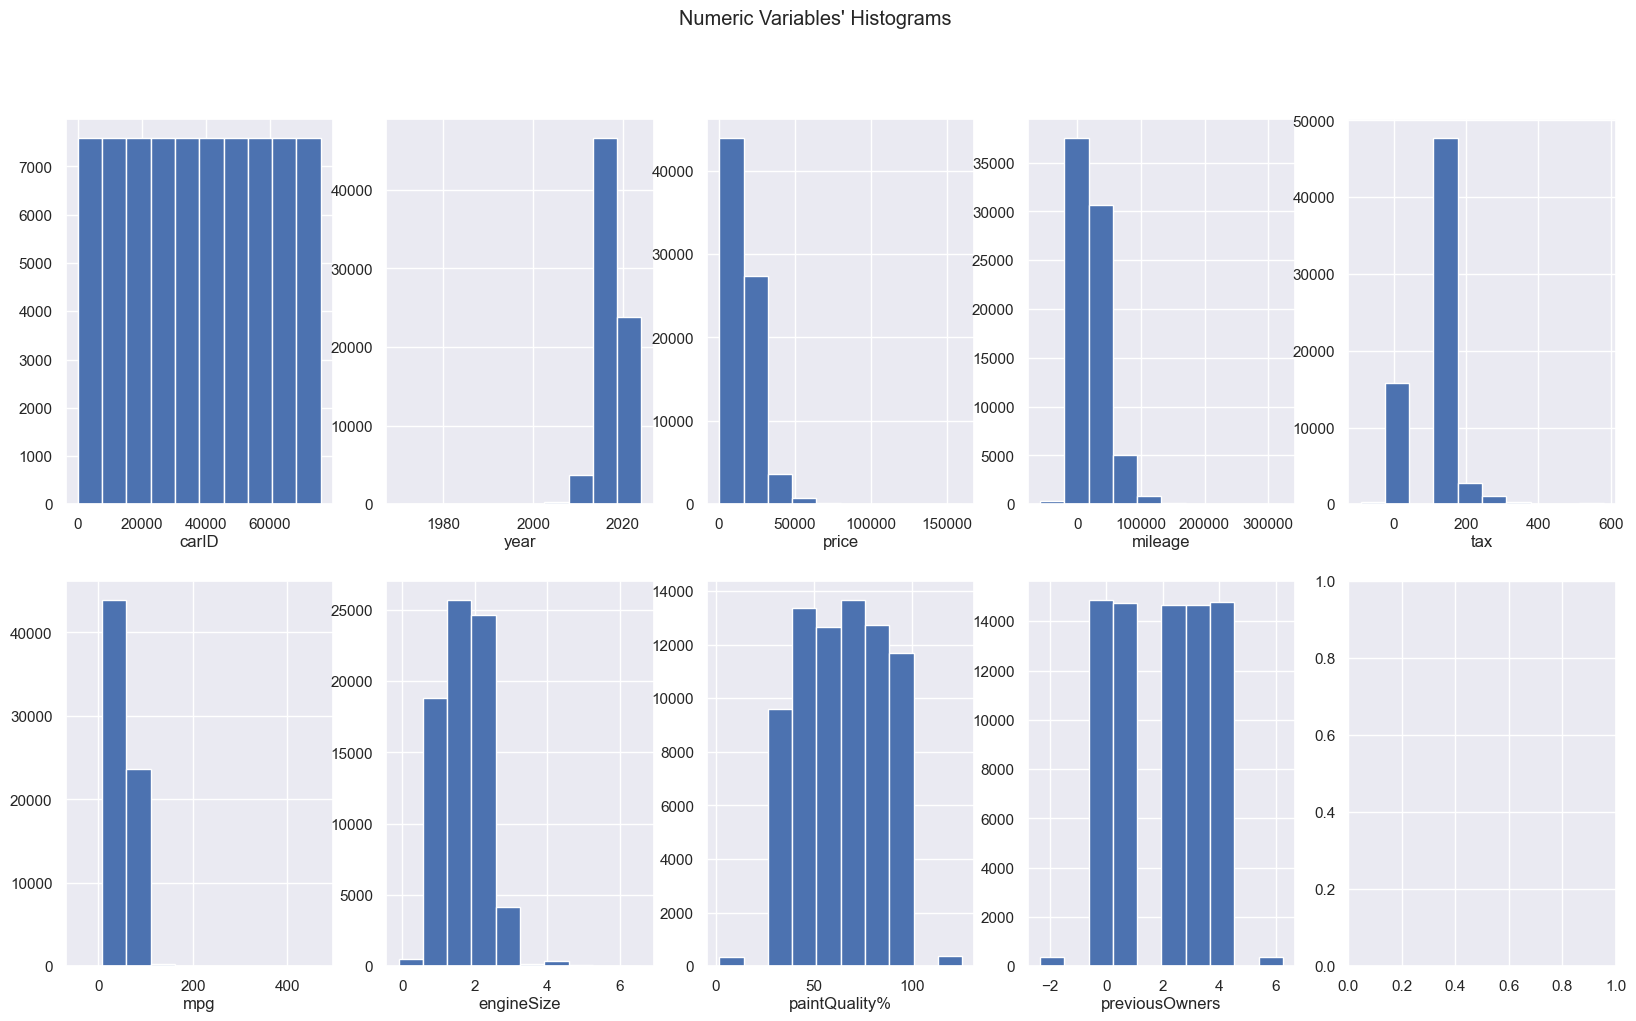

In [29]:
# All Numeric Variables' Histograms in one figure
sns.set()

# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(2, ceil(len(metric_features) / 2), figsize=(20, 11))

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), metric_features): # Notice the zip() function and flatten() method
    ax.hist(cars[feat])
    ax.set_title(feat, y=-0.13)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Histograms"

plt.suptitle(title)

plt.show()

There's a lot of different histograms that we can observe in the numeric variables:
- 'year' is very concentrated in a specific period of time, even though we know that we have some older cars we can't see them in this histogram, we would probably need to use a boxplot to observe the outliers;
- 'price' is very right skewed, with the majority of cars being priced below 50000, with long tail representing the luxury prices, as the maximum price is 160000, a observation could be that using log(price) can give us a more normal distribution more useful for our project;
- 'mileage' is also very right skewed, with most cars falling between 0-100000 miles, with a tail getting to 300000, which is realistic taking into consideration the real world, but might need outlier detection;
- 'previousOwners' looks to have a bimodal distribution, and also seem to have negative values, something to analyse after;
- 'paintQuality%' seems to have a normal distribution, even though it's not useful for the prediction of our target.

#### Box Plot

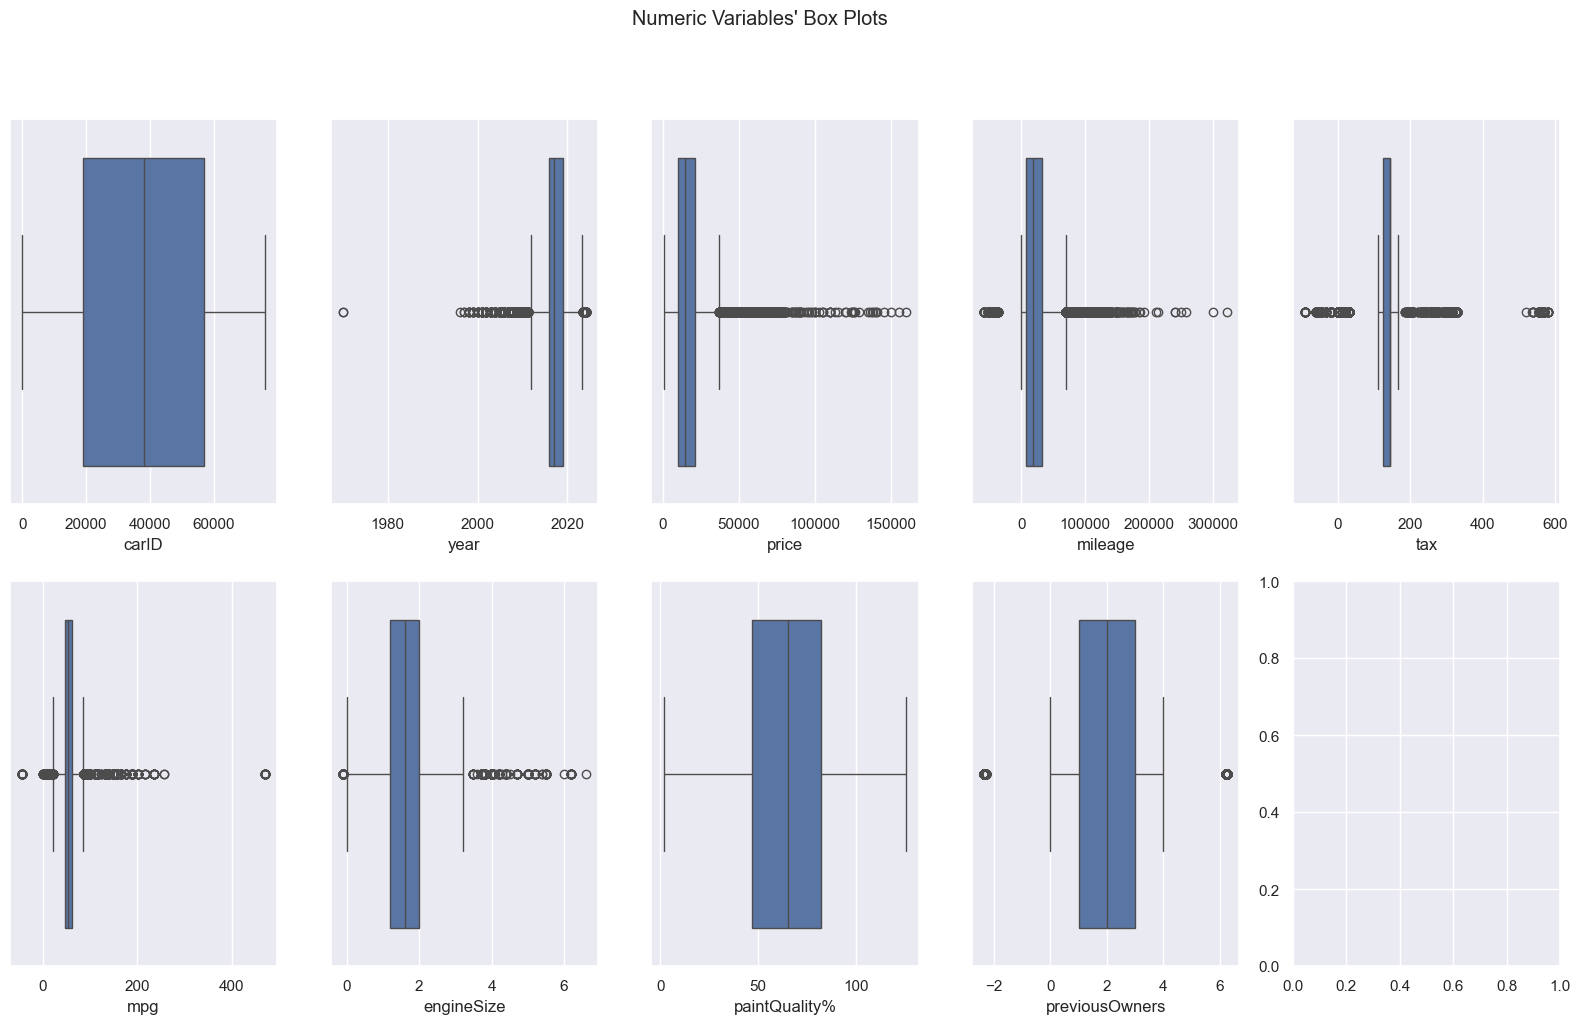

In [30]:
# All Numeric Variables' Box Plots in one figure
sns.set()

# Prepare figure. Create individual axes where each box plot will be placed
fig, axes = plt.subplots(2, ceil(len(metric_features) / 2), figsize=(20, 11))

# Plot data
# Iterate across axes objects and associate each box plot (hint: use the ax argument):
for ax, feat in zip(axes.flatten(), metric_features): # Notice the zip() function and flatten() method
    sns.boxplot(x=cars[feat], ax=ax)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Box Plots"

plt.suptitle(title)

plt.show()

We can notice that almost every numeric feature we have, 'price', 'mileage', 'mpg', 'tax', 'engineSize', 'previousOwners' show a significant number of outliers, showing that we have a lot of diversity and different extreme values, due to this in some of this features we might need to do outlier treatment ('year' only goes to 2020, but there's outliers past it), but in general in the feature 'price' there's a lot of valid data even in the outliers (older cars) which will be essential for our models.

We can observe as well than some features have some anomalies in the data, as it looks as 'mpg', 'mileage', 'previousOwners', 'engineSize' have negative values, which don't make sense in our analysis, so we will have to deal with that data after, a solution to that issue could be getting the absolute value of the data. This way we only get valid results that won't affect our results.

Here it's confirmed our suspections of 'year' having values higher than 2020, and that we have negative values in the feature 'mileage', 'previousOwners' and 'engineSize'

C:\Users\User\AppData\Local\Temp\ipykernel_11824\471253026.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cars_top_brands, x='price', y='Brand', order=order, palette='viridis')


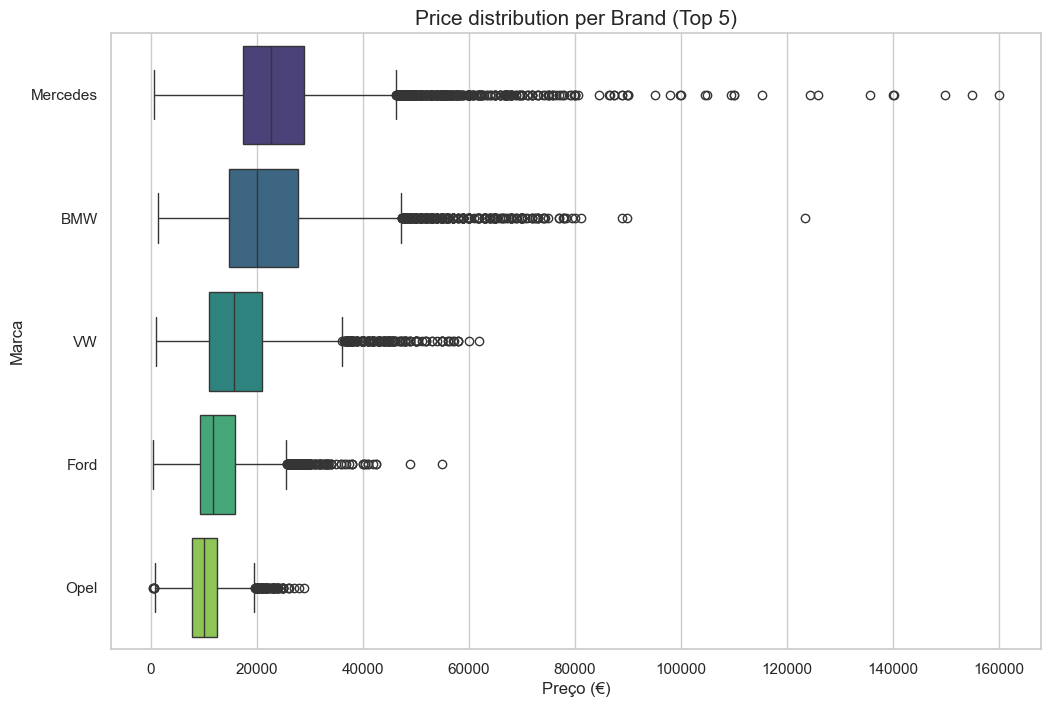

In [57]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Select only top 5 brands (There's 72 brands in total for now)
top_brands = cars['Brand'].value_counts().nlargest(5).index
cars_top_brands = cars[cars['Brand'].isin(top_brands)]

# Define the order of the top brands by median value from highest to lowest
order = cars_top_brands.groupby("Brand")["price"].median().sort_values(ascending=False).index

# Boxplot creation
sns.boxplot(data=cars_top_brands, x='price', y='Brand', order=order, palette='viridis')

# Title and labels
plt.title('Price distribution per Brand (Top 5)', fontsize=15)
plt.xlabel('Preço (€)', fontsize=12)
plt.ylabel('Marca', fontsize=12)

plt.show()

This boxplot of each brand's distribution of price (top 5 more popular) shows us a clear relationship between brand and the price of the vehicle, showing us that it's still a very significant predictor:
- Clear distinction between each brand, with Mercedes being closer to the premium brand, showing higher median prices than Open, Ford and VW, with outliers going higher than any other brand;
- With having this variance between making premium cars, like the Class S, and making more "budget" cars like a A-Class, which explains our wider boxes in this more expensive brands, while "cheaper" ones, like Opel and Ford, have narrower boxes, showing a more consistent and lower price range;
- Every brand show a significantly ammount of outliers on the higher end. This suggest that even cheaper brands usually have a model or another that deviates from the brand's typical price point.

What we get from this boxplot is that 'Brand' is a crucial feature for our regression model, and that we will be encoding with OneHotEncoder, because it avoids ordinal relationships, meaning that we want each feature created from this (is_Ford for example) to have the same value as the others, so the model doesn't mistake one brand to have a higher value than another. 

#### Pair Plot

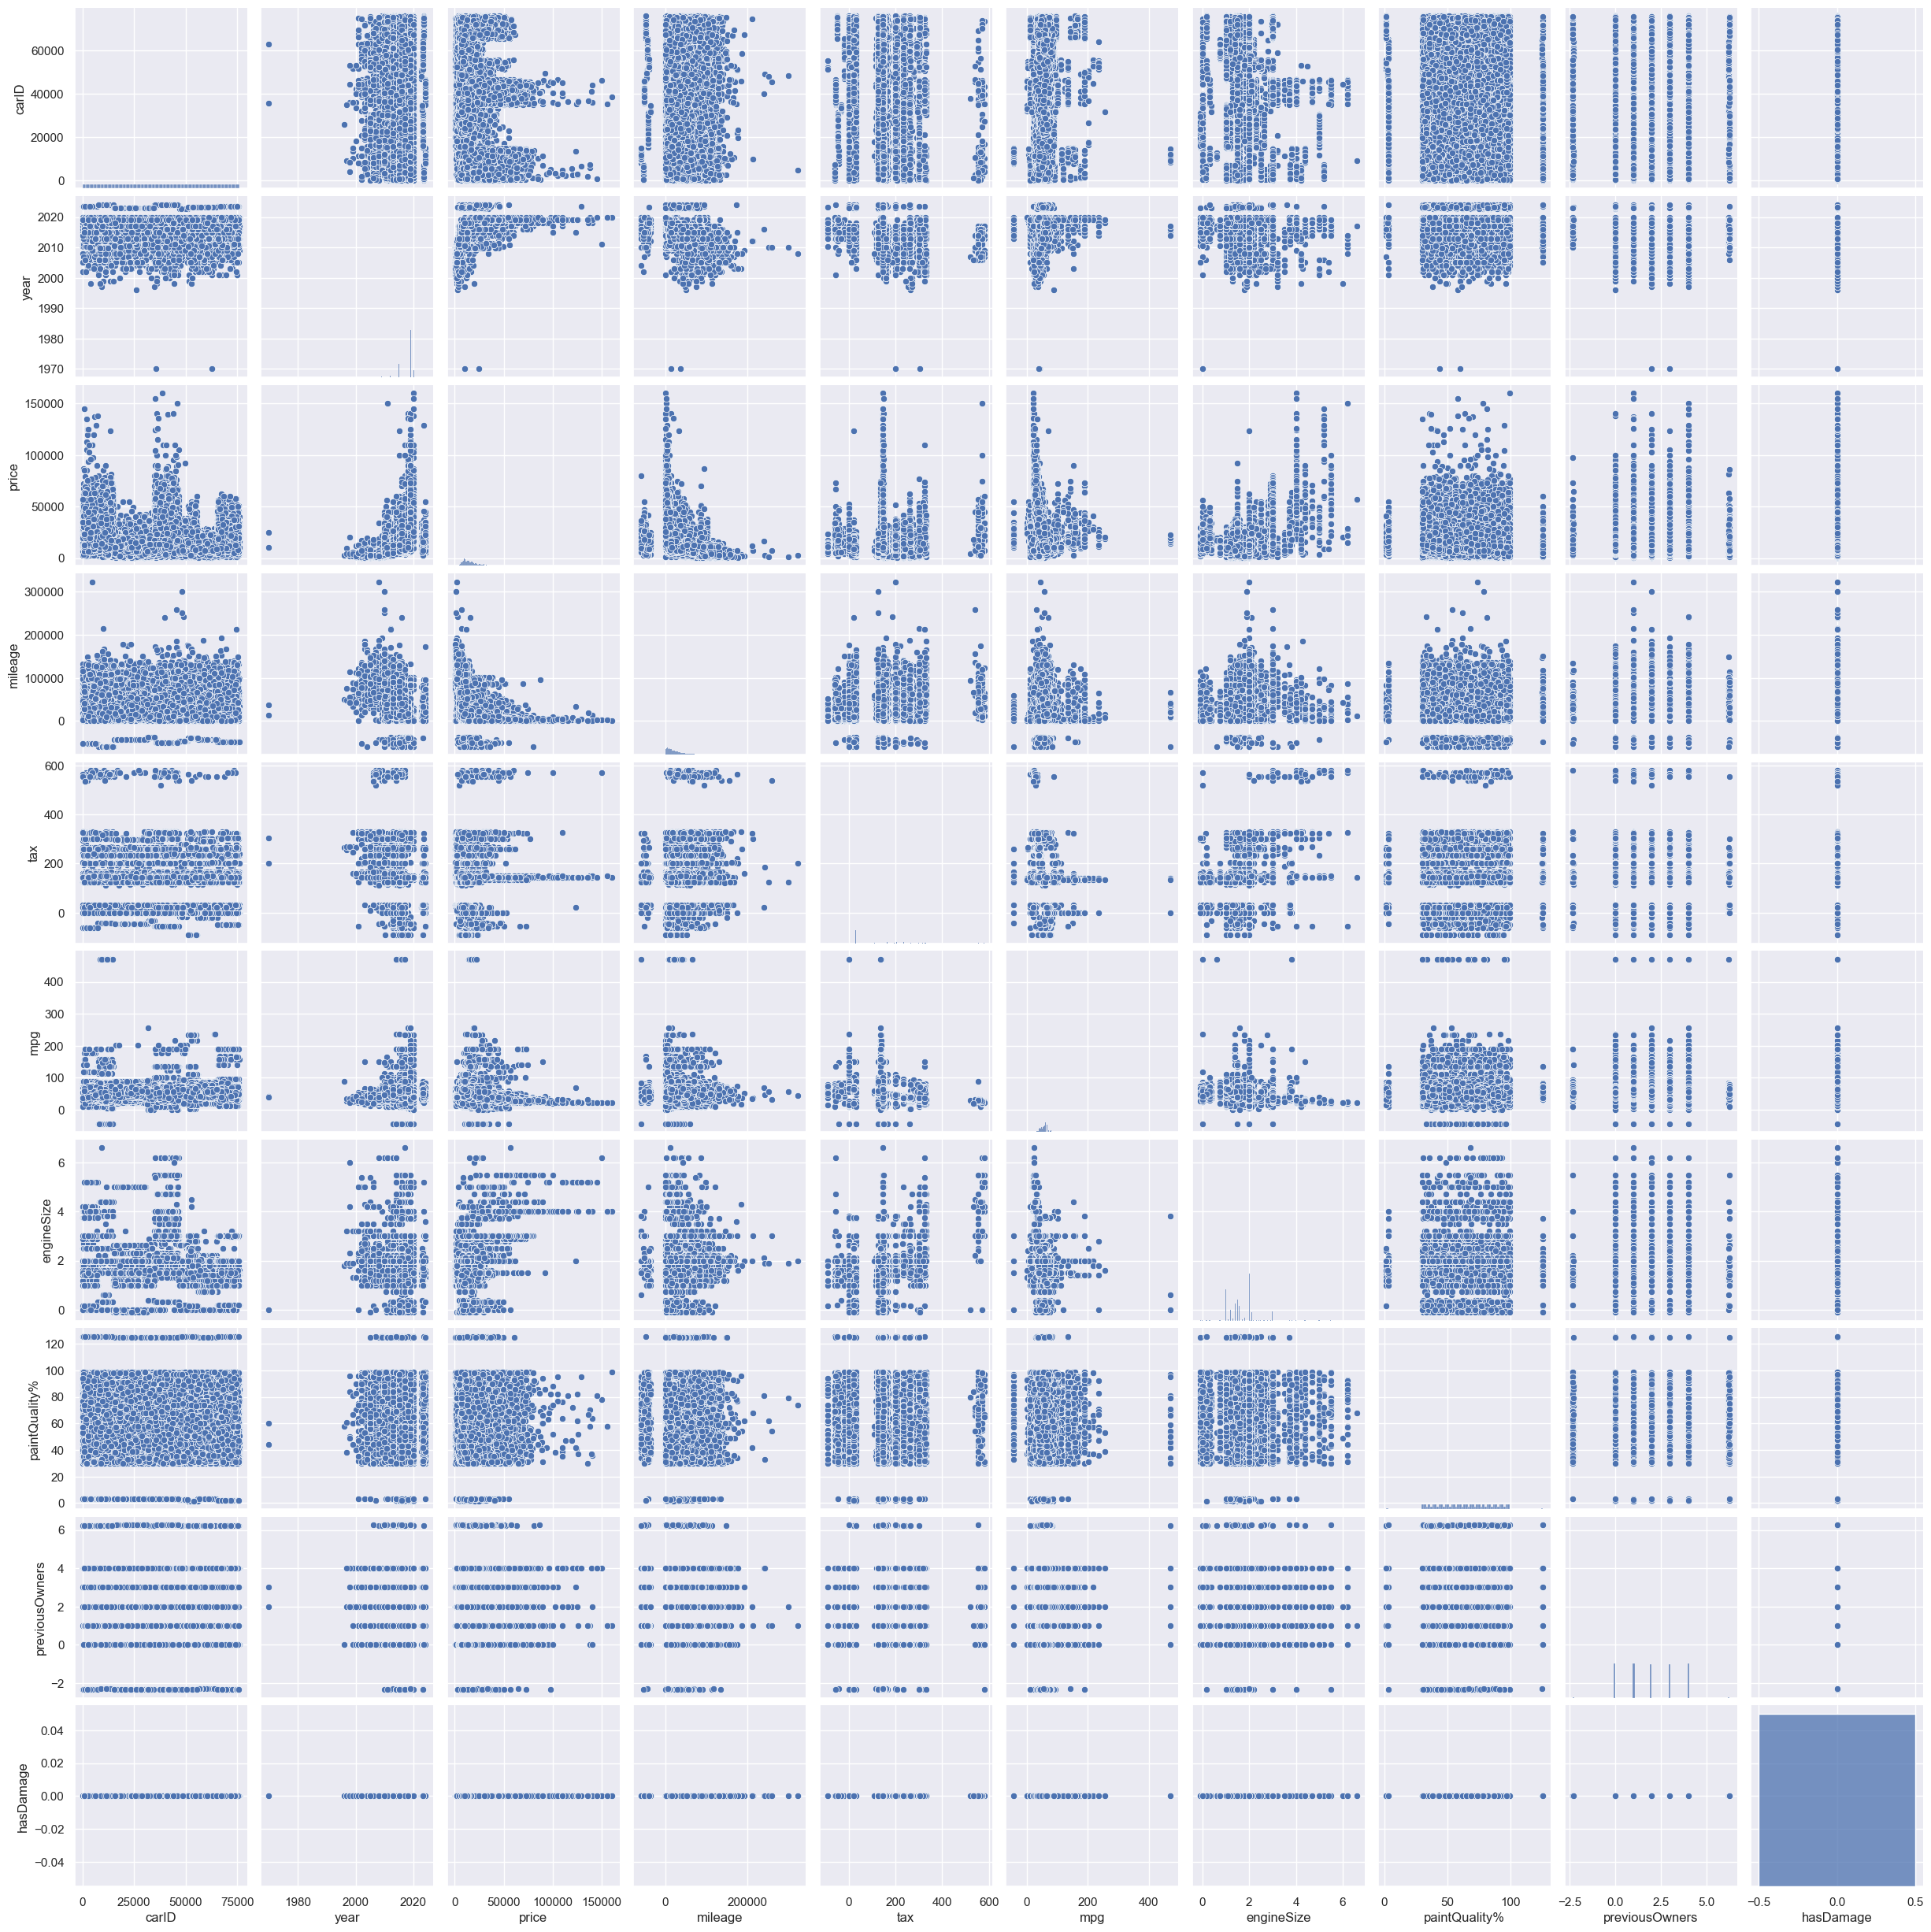

In [32]:
sns.pairplot(cars)
plt.show()

This Pair Plot shows us some interesting insights for our observation:

- Price vs Mileage: We confirm the clear negative relationship between them, as mileage increases, price tends to decrease, which can be understood for example older cars;
- Price vs Year: We can observe the positive relationship between the two, which means that newer cars will generally have higher prices, which we can observe in greater detail in the barplot later created;
- We also see a lack of strong linear relations, both in this pair plot as with the correlation matrix, in which the highest was a score of -0.67 (mileage/year), which means for this dataset, we will have to go through a throughough process of Feature engineering, envolving enconding many of the variables that aren't numerical, as it stands, linear models probably won't have great perfomance as it stands.

In [33]:
#Car's year and price cleaning, rounding year to integer
dfclean = cars.dropna(subset=['year', 'price']).copy()
dfclean['year'] = dfclean['year'].astype(int)

In [34]:
#Outliers in the 'year' feature
Q1 = dfclean['year'].quantile(0.25)
Q3 = dfclean['year'].quantile(0.75)
IQR = Q3 - Q1
low_iqr= Q1 - 1.5 * IQR
high_iqr= Q3 + 1.5 * IQR
dfclean[(dfclean['year'] < low_iqr) | (dfclean['year'] > high_iqr)].shape


(1697, 14)

In [35]:
#Rows within the year 1970
dfclean[dfclean['year'] == 1970]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
11425,62732,OPEL,Zafira,1970,10495,Manual,37357.0,NaN,200.0,42.2,NaN,60.0,2.0,0.0
34917,35769,Mercedes,M Class,1970,24999,Automatic,14000.0,Diesel,305.0,39.2,0.0,44.0,3.0,0.0


In [36]:
#Rows higher than the year 2020
dfclean[dfclean['year'] > 2020]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
35,53282,Toyota,Yaris,2023,16995,Manual,1225.0,Petrol,145.0,47.9,1.5,77.0,0.0,0.0
216,20770,Ford,Kuga,2023,16950,Manual,3376.0,Diesel,145.0,54.3,1.5,68.0,1.0,0.0
590,42947,mercedes,GLE Class,2023,54885,Automatic,10516.0,Diesel,145.0,NaN,3.0,94.0,4.0,0.0
647,22446,Ford,fiesta,2023,10700,manual,8015.0,Petrol,145.0,55.4,1.1,57.0,1.0,0.0
859,11832,BMW,Z4,2024,31350,Automatic,111.0,Petrol,145.0,38.7,2.0,32.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,22614,Ford,KUGA,2023,13998,MANUAL,32544.0,Diesel,145.0,54.3,2.0,65.0,2.0,0.0
74468,75005,VW,Touran,2023,14995,unknown,23746.0,Diesel,30.0,65.7,1.6,53.0,0.0,0.0
74591,44569,Mercedes,C Class,2023,22532,Semi-Auto,20150.0,Petro,NaN,NaN,2.0,60.0,3.0,0.0
74900,57384,Opel,Mokka,2023,7299,Manual,56136.0,Diesel,30.0,62.8,1.7,57.0,4.0,0.0


#### Mean Price by Year

With the knowledge discovered from the correlation Matrix we decided to explore the correlation between the average price per year.

Here we saw:
- A decline in the car's price as the year diminuishes;
- A spike in the year 1970, mainly because there's only 2 cars and the price can be inflated due to the status of the car becoming a "antique";
- A spike in the year 2020, that can be justified due to the COVID-19 pandemic;
- That we have irrelevant outliers for our project (The dataset consists only of cars until 2020), so we will remove the rows that have the 'year' feature above 2020;
- We do have a lot of outliers apart from that, and in the 'year' feature we consider this outliers valid data points

We see that 'year' is a strong predictor for our target, so we will want to keep it come the feature selection process.

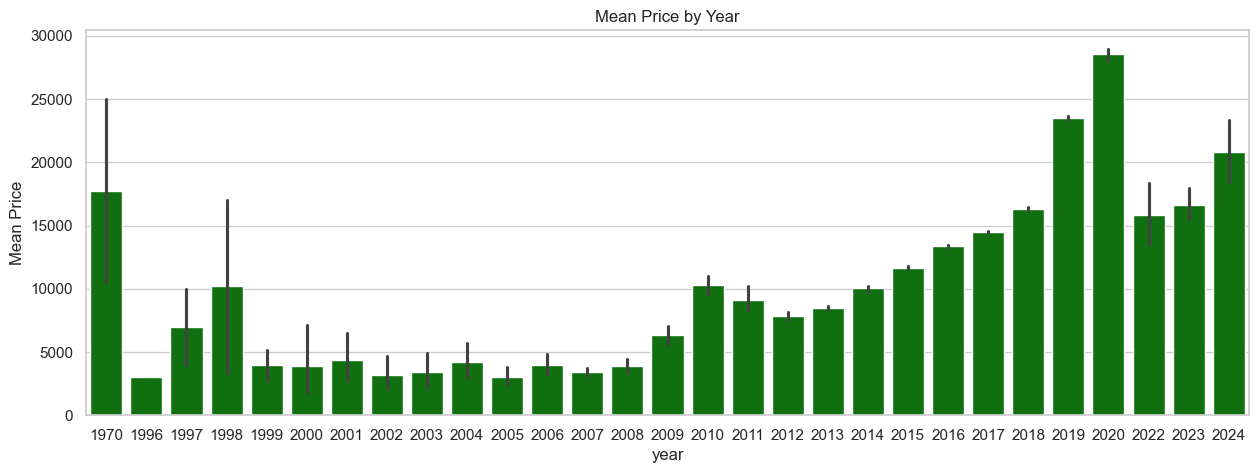

In [37]:
fig = plt.figure(figsize=(15, 5))
sns.set_style("whitegrid")
sns.barplot(data=dfclean, x="year", y="price", estimator="mean", color="green")
plt.title("Mean Price by Year")
plt.ylabel("Mean Price")
plt.show()

#### Mean Mileage by Year

Another of the relevant features we saw in the correlation Matrix was the 'mileage' feature, in which it has a correlation of -0.41 with price, and a -0.67 correlation core with the feature 'year'

Here we saw:
- Older cars have a higher mileage until 2004;
- An all time low in 2020, which makes sense because of the COVID-19 pandemic meaning we had to stay in quarantine;
- As we saw in the 'price' feature, we have irrelevant outliers for our project (The dataset consists only of cars until 2020), so we will remove the rows that have the 'year' feature above 2020;
- Because it's not related with the target feature, it's not as relevant to be refering it, but either way it's important to have an idea of how the 'mileage' feature distributes itself throughout the years;

We have a normal distribution of the 'mileage' throughout the 'year' feature. This will be important in the Feature Engineering part of the project, in which we can use this two features to improve our model.

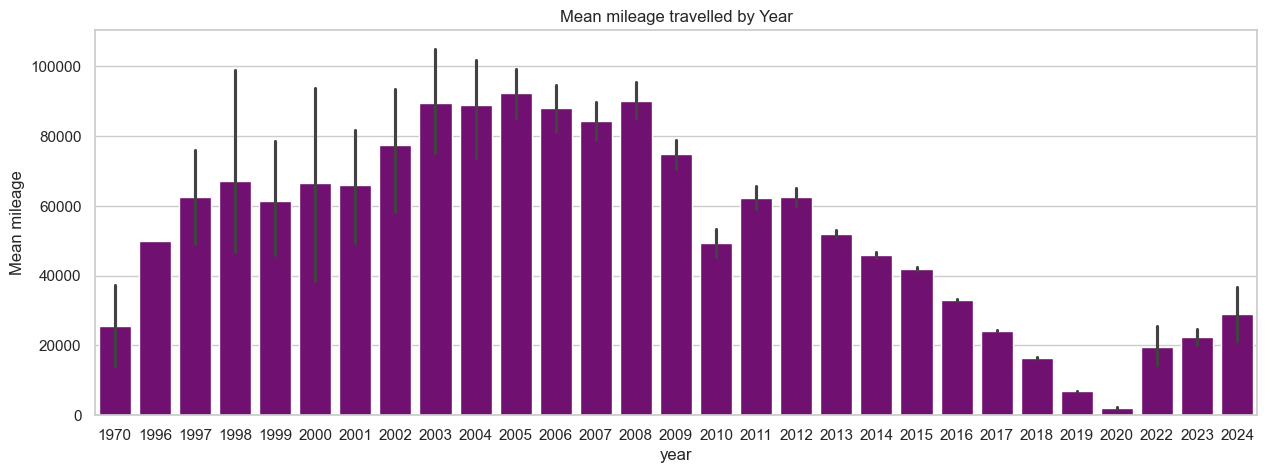

In [ ]:
fig = plt.figure(figsize=(15, 5))

sns.set_style("whitegrid")

sns.barplot(data=dfclean, x="year", y="mileage", estimator="mean", color="purple")
plt.title("Mean mileage travelled by Year")
plt.ylabel("Mean mileage")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_11824\333794427.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cars, x='price', y='transmission', order= ['Manual', 'Semi-Auto', 'Automatic'], palette='viridis')


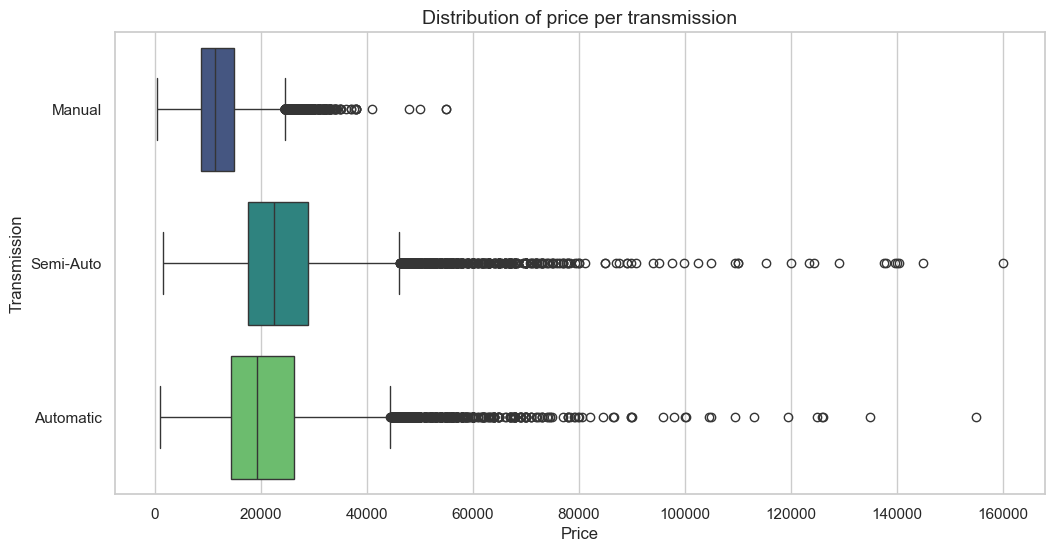

In [84]:
# Plot Price vs Fuel Type boxplot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Create order based on median price
order_trans = cars.groupby("transmission")["price"].median().sort_values(ascending=False).index

sns.boxplot(data=cars, x='price', y='transmission', order= ['Manual', 'Semi-Auto', 'Automatic'], palette='viridis')
plt.title('Distribution of price per transmission', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Transmission', fontsize=12)

plt.show()

In this transmission boxplot we can see:
- Manual is the cheapest type of vehicle following the median, this makes sense, it's the simplest type and the most common, as we see in the count plot after, more than both semi-auto and automatic combined. It also has a narrower box and fewer outliers which confirms that they represent the affordable segment of the dataset;
- Semi-Auto and Automatic have both higher median prices compared to Manual cars, this alligns with the fact that in premium and luxury segments of cars, automatic transmissions are considered standard, while the manual are more in economy models. These both types of transmission have wider boxes and a very high number of outliers, with even though being more expensive than manual, there still exists a lot of outliers, going all the way through to 160000 euros.

Following this boxplot, we can confirm that due to the distinct values between manual vehicles and the rest, that the type of transmission is gonna be useful for predicting the price. So in the preprocessing phase this will be subject as well to Encoding and Rapid Fuzz matching to both turn categorical data into numeric, and group the main types of transmissions with typos made during data insertion (anual meaning Manual).

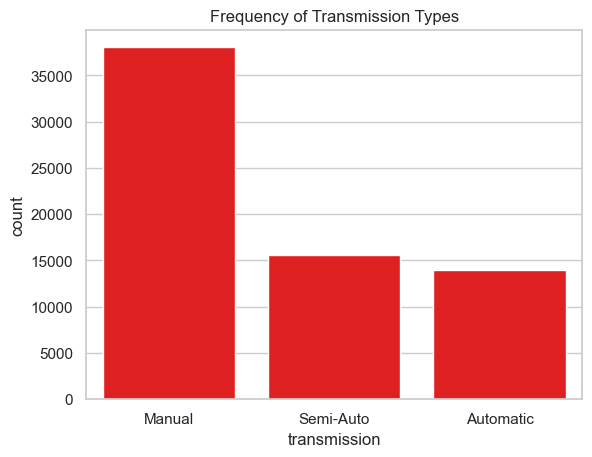

In [39]:
sns.set() # this resets our formatting defaults

#Set the style of the plots to whitegrid
sns.set_style("whitegrid")

sns.countplot(x=cars["transmission"], color = "red", order= cars['transmission'].value_counts().head(3).index)
plt.title("Frequency of Transmission Types")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_11824\2474109102.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cars, x='price', y='fuelType', order= ['Petrol', 'Diesel', 'Hybrid'], palette='viridis')


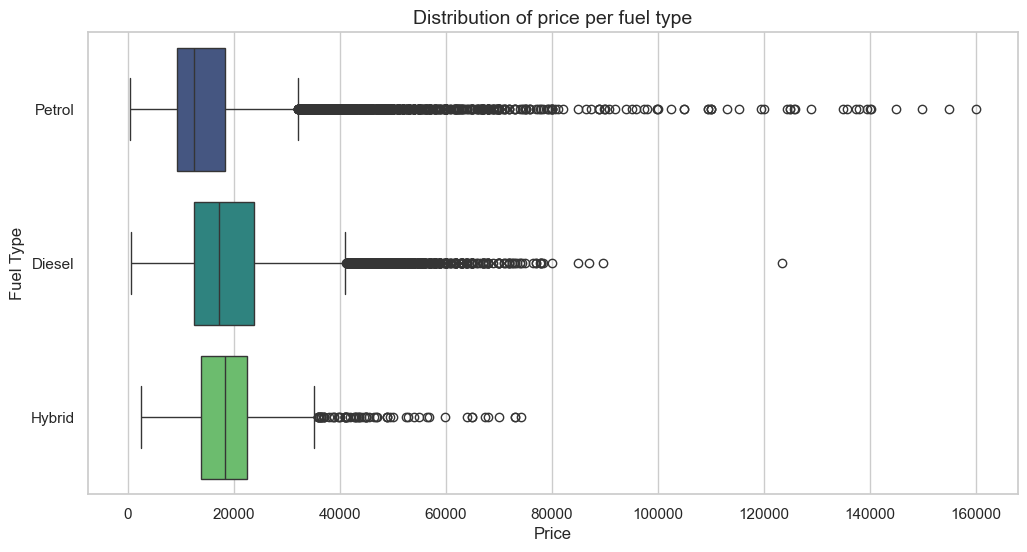

In [78]:
# Plot Price vs Fuel Type boxplot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Create order based on median price
order_trans = cars.groupby("fuelType")["price"].median().sort_values(ascending=False).index

sns.boxplot(data=cars, x='price', y='fuelType', order= ['Petrol', 'Diesel', 'Hybrid'], palette='viridis')
plt.title('Distribution of price per fuel type', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Fuel Type', fontsize=12)

plt.show()

In this distribution of car prices by fuel types, we can observe a lot of informations:
- Petrol is the cheapest and with the highest variance, even though is has a box relatively normal size compared to the others, however, it has the highest ammount of number of outliers by a mile, this can be explained by it being the most common fuel type of them all, meaning that with a mix of affordable cars and high-perfomance sports vehicles it's normal to have such high numbers of outliers;
- Diesel vehicles are generally prices higher than the Petrol counterparts, usually because diesel engines are built tougher to handle high compression, as well as coming with extra features like DPFs (Diesel Particulate Filters) to keep emissions in check. However, petrol still has outliers with a higher value than Diesel vehicles, which means that probably the high ammount of affordable petrol cars downplays the median value;
- Hybrid has the highest median value of all the types, this usually being because the added cost and complexity of electrification, like the battery pack and electric motor. Could also be explained by the far lower frequency compared to the other fuel types, as we are gonna see in the next count plot.

The close yet distinct median prices across these three groups tells us that fuelType remains a strong predictor for prices, which means it will be subjected to the OneHotEncoder aswell.

P.S.: This exploratory analysis was made before the pre processing phase, which means we still have a lot of issues like typos in the Brands, Fuel Types, Models and Transmission features, this was made to have an idea  of how the distribution looks like, however this won't be the actual final distribution of the features mentioned.

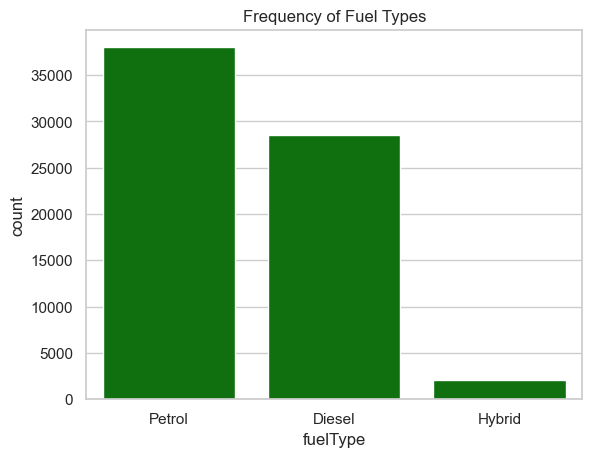

In [77]:
sns.set() # this resets our formatting defaults

#Set the style of the plots to whitegrid
sns.set_style("whitegrid")

sns.countplot(x=cars["fuelType"], color = "green", order= cars['fuelType'].value_counts().head(3).index)
plt.title("Frequency of Fuel Types")
plt.show()

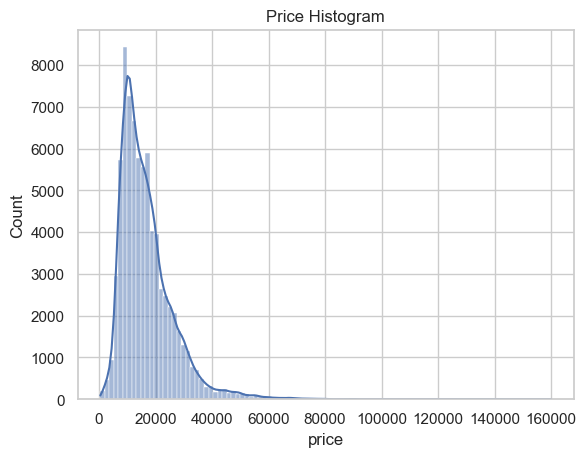

In [41]:
sns.set() # this resets our formatting defaults

sns.set_style("whitegrid")

sns.histplot(cars['price'], kde=True, bins=100)
plt.title("Price Histogram")
plt.show()

This was made only to have an idea of the frequency of the price throughout the whole dataset, showing us that it's mainly affordable cars, with a long tail (a lot of outliers)

C:\Users\User\AppData\Local\Temp\ipykernel_11824\1556259876.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


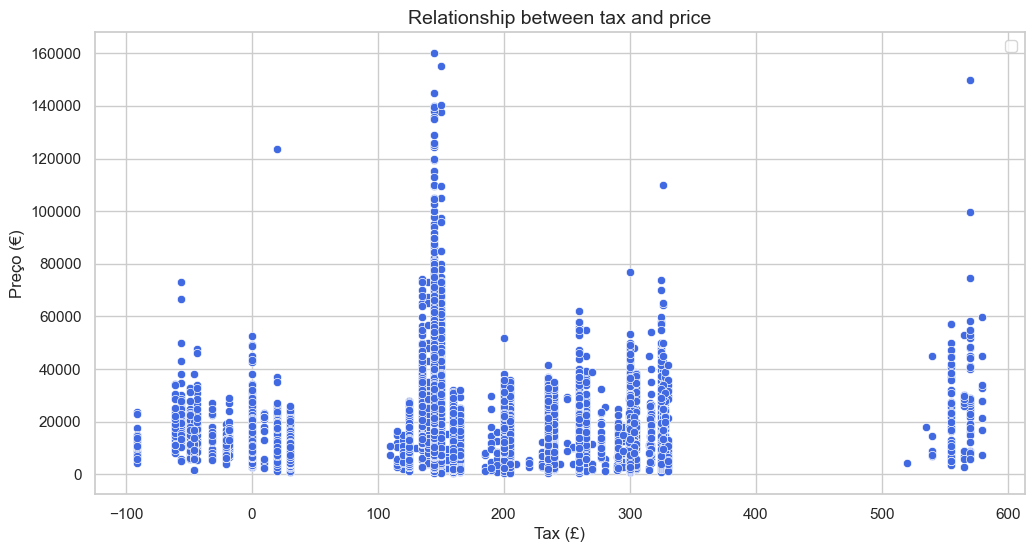

In [ ]:
plt.figure(figsize=(12, 6))

# Scatter plot between tax and price
sns.scatterplot(data=cars, x='tax', y='price', color='royalblue')

plt.title('Relationship between tax and price', fontsize=14)
plt.xlabel('Tax (£)', fontsize=12)
plt.ylabel('Preço (€)', fontsize=12)
plt.legend()

plt.show()

In this final graph we see the relationship between tax and price in greater detail. We can take a few observations here:
- We have a lot of negative values in this feature, which we will be dealing in the preprocessing step using the absolute values;
- While tax is a numeric value, the vertical lines that we can see in the scatter plot shows us that it clusters around specific bands, this reflects that there exists tax regulations instead of a continuous distribution.

As it looks, there doesn't seem to be a real correlation between price and tax, however, we are going to cluster these values between different groups representing different tax brackets, which while it might not be very useful to a linear regression, it can be for a tree style of model, in which it searches for patterns between certain features.

We can now move to the PreProcessing phase of our project